In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
from pypower.loadcase import loadcase
from scipy.io import loadmat
from pymatreader import read_mat

from pathlib import Path
import os
import sys

sys.path.append("../utils")
from matpower_io import load_matpower_case

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import haversine
import geopandas as gpd

## Download Texas County Shapes

In [106]:
from zipfile import ZipFile
import requests
import json
import io

In [109]:
r = requests.get('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_5m.zip')
print(r.status_code)
zf = ZipFile(io.BytesIO(r.content))
zf.extractall()

200


In [110]:
gdf = gpd.read_file('cb_2018_us_county_5m.shp')
gdf.head()

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,39,071,01074048,0500000US39071,39071,Highland,06,1432479992,12194983,"POLYGON ((-83.86976 39.05553, -83.86568 39.247..."
1,06,003,01675840,0500000US06003,06003,Alpine,06,1912292630,12557304,"POLYGON ((-120.07248 38.50987, -120.07239 38.7..."
2,12,033,00295737,0500000US12033,12033,Escambia,06,1701544502,563927612,"POLYGON ((-87.62999 30.87766, -87.62946 30.880..."
3,17,101,00424252,0500000US17101,17101,Lawrence,06,963936864,5077783,"POLYGON ((-87.91028 38.57493, -87.90811 38.850..."
4,28,153,00695797,0500000US28153,28153,Wayne,06,2099745573,7255476,"POLYGON ((-88.94317 31.78421, -88.94336 31.824..."


In [123]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3233 entries, 0 to 3232
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   3233 non-null   object  
 1   COUNTYFP  3233 non-null   object  
 2   COUNTYNS  3233 non-null   object  
 3   AFFGEOID  3233 non-null   object  
 4   GEOID     3233 non-null   object  
 5   NAME      3233 non-null   object  
 6   LSAD      3233 non-null   object  
 7   ALAND     3233 non-null   int64   
 8   AWATER    3233 non-null   int64   
 9   geometry  3233 non-null   geometry
dtypes: geometry(1), int64(2), object(7)
memory usage: 252.7+ KB


In [124]:
tx_fp = us.states.lookup('texas').fips

<Axes: >

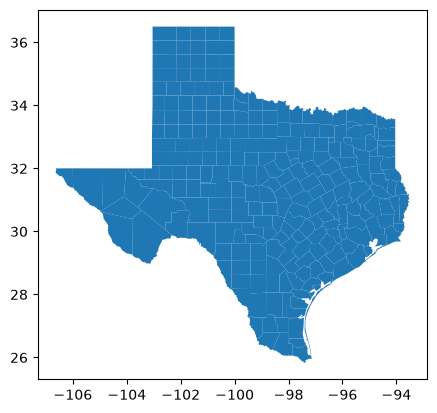

In [126]:
gdf.loc[gdf['STATEFP']==tx_fp].plot()

In [ ]:
import us

## Process TAMU network

In [2]:
tamu_path = Path("../../../2021TXPowerOutage")
os.listdir(tamu_path/"bte2k")

['case_Mar3_5pm.mat', 'design3.mat', 'hvdc_upgraded.mat']

In [3]:
ppc, extras = load_matpower_case(tamu_path/"bte2k/case_Mar3_5pm.mat")

In [4]:
extras.keys()

dict_keys(['zone', 'sub', 'subid', 'busid', 'bus2sub', 'genid', 'genfuel', 'genfuelcost', 'heatratecurve', 'branchid', 'branchdevicetype'])

In [5]:
n = pypsa.Network() 
n.import_from_pypower_ppc(ppc, overwrite_zero_s_nom=1e6)
n.generators['carrier'] = extras['genfuel']

In [6]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 2000
 - Generator: 606
 - Line: 2359
 - Load: 1125
 - ShuntImpedance: 150
 - Transformer: 847
Snapshots: 1

In [7]:
mpc_dict = read_mat(tamu_path/"bte2k/case_Mar3_5pm.mat")['mpc']

In [8]:
mpc_dict.keys()

dict_keys(['version', 'baseMVA', 'zone', 'sub', 'subid', 'bus', 'busid', 'bus2sub', 'gen', 'genid', 'genfuel', 'genfuelcost', 'heatratecurve', 'branch', 'branchid', 'branchdevicetype', 'gencost'])

In [9]:
bus2sub = pd.DataFrame(mpc_dict['bus2sub'], columns=['subid','state'])
bus2sub['busid'] = mpc_dict['busid']

In [10]:
sub_geo = pd.DataFrame(mpc_dict['sub'], columns=['name','idx','y','x','state'])

In [11]:
sub_geo['subid'] = mpc_dict['subid']

In [12]:
bus_geo = pd.merge(sub_geo, bus2sub, on=['state','subid'])

In [13]:
bus_geo = bus_geo.set_index(['busid'])
bus_geo.index.name = 'name'

In [14]:
n.buses[['x','y']] = bus_geo[['x','y']].values

In [36]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 2000
 - Generator: 606
 - Line: 2359
 - Load: 1125
 - ShuntImpedance: 150
 - Transformer: 847
Snapshots: 1

In [40]:
n.generators.carrier.unique()

array(['wind', 'solar', 'ng', 'coal', 'hydro', 'nuclear', 'other'],
      dtype=object)

In [41]:
colors = ["dodgerblue",
    "gold",
    "darkorange",
    "black",
    "blue",
    "magenta",
    "red",]

In [35]:
n.carriers

attribute,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,


In [46]:
n.add(class_name="Carrier", name=n.generators.carrier.unique(), color=colors)

In [47]:
n.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,
wind,0.0,dodgerblue,,inf,0.0
solar,0.0,gold,,inf,0.0
ng,0.0,darkorange,,inf,0.0
coal,0.0,black,,inf,0.0
hydro,0.0,blue,,inf,0.0
nuclear,0.0,magenta,,inf,0.0
other,0.0,red,,inf,0.0


In [58]:
n.plot?

Signature:     
n.plot(
    ax: 'Axes | None' = None,
    projection: 'Any' = None,
    geomap: 'bool' = True,
    geomap_resolution: "Literal['10m', '50m', '110m']" = '50m',
    geomap_color: 'dict | bool | None' = None,
    title: 'str' = '',
    boundaries: 'tuple[float, float, float, float] | None' = None,
    branch_components: 'list | set | None' = None,
    bus_size: 'float | dict | pd.Series' = 0.02,
    bus_split_circle: 'bool' = False,
    bus_color: 'str | dict | pd.Series' = None,
    bus_cmap: 'str | mcolors.Colormap | None' = None,
    bus_cmap_norm: 'mcolors.Normalize | None' = None,
    bus_alpha: 'float | dict | pd.Series' = 1,
    geometry: 'bool' = False,
    line_flow: 'float | str | Callable | dict | pd.Series' = None,
    line_color: 'str | dict | pd.Series' = 'rosybrown',
    line_cmap: 'str | mcolors.Colormap' = 'viridis',
    line_cmap_norm: 'mcolors.Normalize | None' = None,
    line_alpha: 'float | dict | pd.Series' = 1,
    line_width: 'float | dict | pd.Ser

In [63]:
n.branch_components

{'Line', 'Link', 'Process', 'Transformer'}

In [98]:
n.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,
wind,0.0,dodgerblue,,inf,0.0
solar,0.0,gold,,inf,0.0
ng,0.0,darkorange,,inf,0.0
coal,0.0,black,,inf,0.0
hydro,0.0,blue,,inf,0.0
nuclear,0.0,magenta,,inf,0.0
other,0.0,red,,inf,0.0


In [102]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 2000
 - Carrier: 7
 - Generator: 606
 - Line: 2359
 - Load: 1125
 - ShuntImpedance: 150
 - Transformer: 847
Snapshots: 1

In [101]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,rateB,rateC,status,original_index
name,,,,,,,,,,,,,,,,,,,,,
L0,3001001,3001064,,4.734550,0.692990,0.0,0.000046,221.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
L1,3001001,3001064,,2.367275,0.692990,0.0,0.000046,442.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
L2,3001001,3001071,,3.713580,0.575287,0.0,0.000041,221.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
L3,3001001,3001071,,1.856790,0.575287,0.0,0.000041,442.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3
L4,3001002,3001007,,61.751493,10.283760,0.0,0.000479,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L2354,3008136,3008145,,6.113918,1.397883,0.0,0.000053,149.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3192
L2355,3008138,3008146,,15.888515,2.781218,0.0,0.000136,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3193
L2356,3008152,3008160,,4.960698,0.711505,0.0,0.000046,221.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3198


In [ ]:
gdf.to_crs?

In [133]:
n.plot?

Signature:     
n.plot(
    ax: 'Axes | None' = None,
    projection: 'Any' = None,
    geomap: 'bool' = True,
    geomap_resolution: "Literal['10m', '50m', '110m']" = '50m',
    geomap_color: 'dict | bool | None' = None,
    title: 'str' = '',
    boundaries: 'tuple[float, float, float, float] | None' = None,
    branch_components: 'list | set | None' = None,
    bus_size: 'float | dict | pd.Series' = 0.02,
    bus_split_circle: 'bool' = False,
    bus_color: 'str | dict | pd.Series' = None,
    bus_cmap: 'str | mcolors.Colormap | None' = None,
    bus_cmap_norm: 'mcolors.Normalize | None' = None,
    bus_alpha: 'float | dict | pd.Series' = 1,
    geometry: 'bool' = False,
    line_flow: 'float | str | Callable | dict | pd.Series' = None,
    line_color: 'str | dict | pd.Series' = 'rosybrown',
    line_cmap: 'str | mcolors.Colormap' = 'viridis',
    line_cmap_norm: 'mcolors.Normalize | None' = None,
    line_alpha: 'float | dict | pd.Series' = 1,
    line_width: 'float | dict | pd.Ser

In [134]:
gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

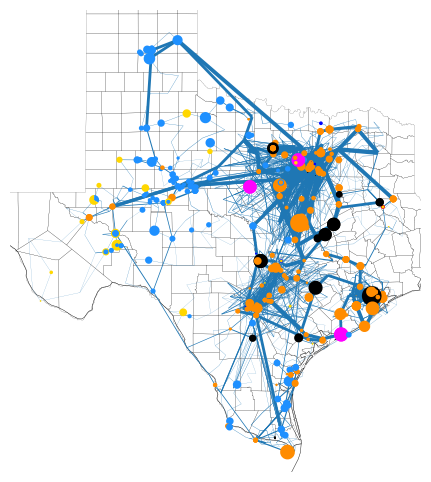

In [144]:
fig, ax = plt.subplots(figsize=(8,6),
                       subplot_kw={'projection': ccrs.Mercator()}
                       )
n.plot(ax=ax, 
      
       bus_size=n.generators.groupby(['bus', 'carrier']).p_nom.sum()/4e4,
    #    bus_split_circle=True,
    #    bus_size=0.002
       line_alpha=1,
       line_color='tab:blue',
       line_width=n.lines.s_nom / 1e3,
      #  branch_components = ['Line', 'Transformer']
       branch_components = ['Line']
       )
gdf.loc[gdf['STATEFP']==tx_fp].to_crs(epsg=3857).plot(ax=ax, zorder=0, fc='None', ec='k', lw = 0.1)
plt.show()

In [105]:
import zipfile

In [72]:
buses_geo

,x,y
name,,
3001001,-102.2620,31.9067
3001002,-104.5190,29.8880
3001003,-101.6480,32.9264
3001004,-101.6480,32.9264
3001005,-101.3880,32.2075
...,...,...
3008156,-96.6950,31.0919
3008157,-96.6950,31.0919
3008158,-96.4608,30.7217


In [70]:
buses_geo = n.buses[['x','y']].copy()

In [73]:
transformers = n.transformers[['bus0','bus1']].copy()

In [76]:
from haversine import haversine, Unit

In [ ]:
for c in b.iterrows():
    print(c.loc[t])

('3001001', v_nom              115.0
type                    
x               -102.262
y                31.9067
carrier               AC
unit                    
location                
v_mag_pu_set    0.998372
v_mag_pu_min         0.9
v_mag_pu_max         1.1
control               PQ
generator               
sub_network             
Pd                 20.78
Qd                  5.89
Gs                   0.0
Bs                   0.0
area               301.0
v_ang_set       -22.3462
zone                 9.0
Name: 3001001, dtype: object)
('3001002', v_nom             115.0
type                   
x              -104.519
y                29.888
carrier              AC
unit                   
location               
v_mag_pu_set    1.02291
v_mag_pu_min        0.9
v_mag_pu_max        1.1
control              PQ
generator              
sub_network            
Pd                15.41
Qd                 4.37
Gs                  0.0
Bs                  0.0
area              301.0
v_ang_set     

In [ ]:
t=n.transformers
b=n.buses
L=pd.Series([haversine((b.loc[c.bus0,'y'], 
                        b.loc[c.bus0,'x']),
               (b.loc[c.bus1,'y'],
                b.loc[c.bus1,'x'])) for c in t.itertuples()])
same_v=(b.loc[t.bus0,'v_nom'].values==b.loc[t.bus1,'v_nom'].values)
print(pd.DataFrame({'len_km':np.round(L,1),'same_v':same_v})
      .assign(bucket=np.where(L<1,'co-located OK',
              np.where(same_v,'same-V + long: misclassified/tap-set line',
                              'diff-V + long: coordinate/join issue')))
      .bucket.value_counts())

bucket
co-located OK                           692
diff-V + long: coordinate/join issue    155
Name: count, dtype: int64
